In [1]:
%pip install pm4py pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 18.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 7.6 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 25.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pm4py]32m2/3 [pm4py]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install graphviz


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip




  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




PM4Py 2.7.23.8


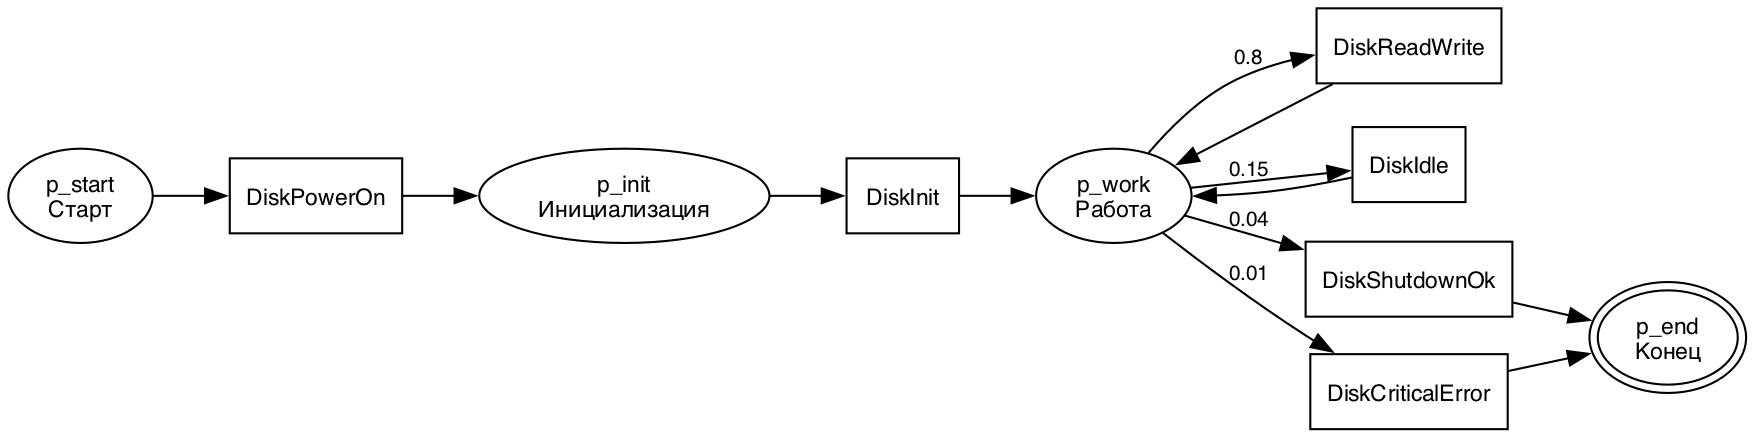

simple_disk: 1000 сессий, 270506 событий


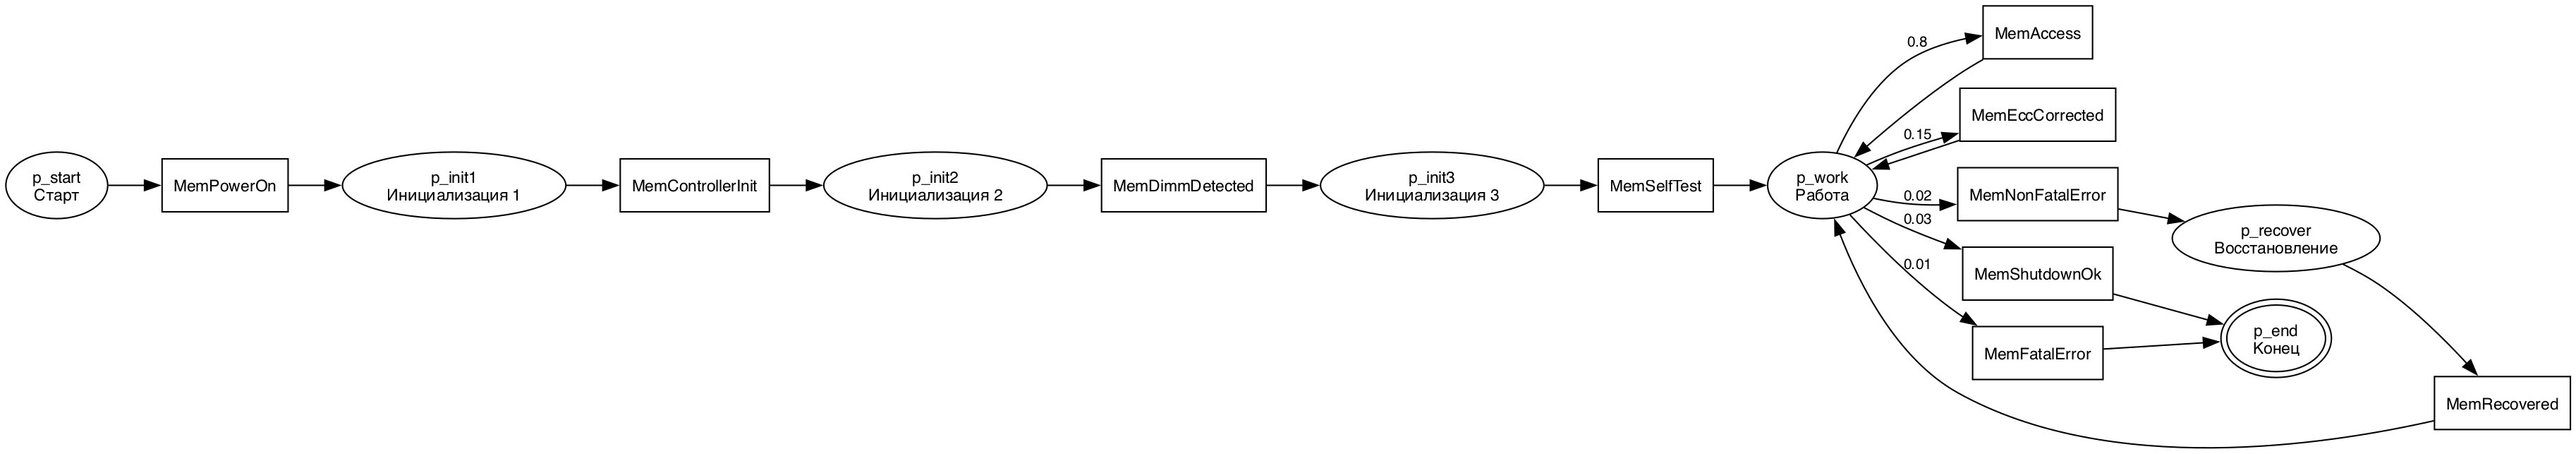

medium_memory: 1000 сессий, 277111 событий


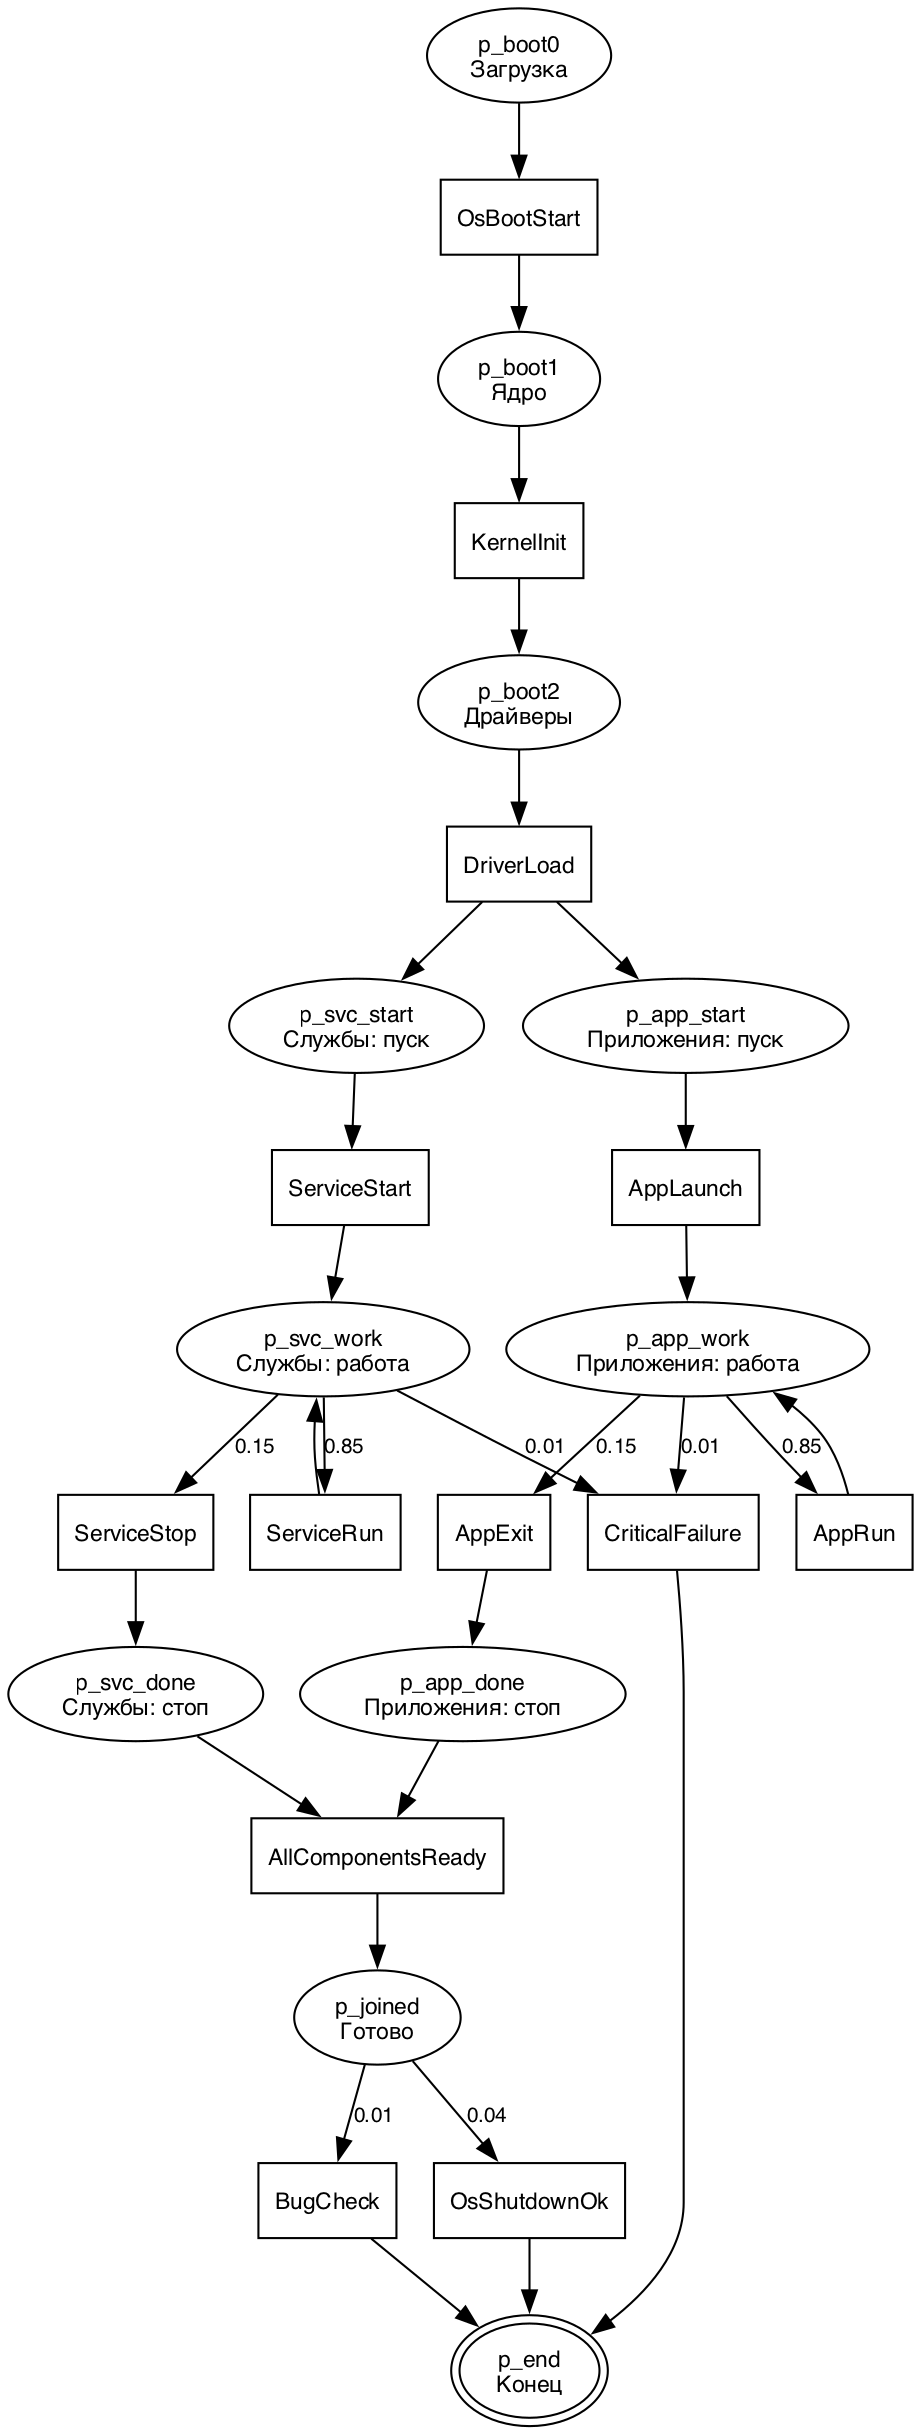

complex_os: 1000 сессий, 267163 событий

Пример данных (simple_disk):
== simple_disk ==
OK   | число сессий = 1000
OK   | мин. длина сессии >= 100
OK   | первое событие сессии — запуск
OK   | последнее событие сессии — терминальное
OK   | типов событий <= лимита
OK   | обязательные поля не пусты
INFO | средняя длина сессии: 270.5
INFO | мин. длина: 105, макс. длина: 517
== medium_memory ==
OK   | число сессий = 1000
OK   | мин. длина сессии >= 100
OK   | первое событие сессии — запуск
OK   | последнее событие сессии — терминальное
OK   | типов событий <= лимита
OK   | обязательные поля не пусты
INFO | средняя длина сессии: 277.1
INFO | мин. длина: 102, макс. длина: 525
== complex_os ==
OK   | число сессий = 1000
OK   | мин. длина сессии >= 100
OK   | первое событие сессии — запуск
OK   | последнее событие сессии — терминальное
OK   | типов событий <= лимита
OK   | обязательные поля не пусты
INFO | средняя длина сессии: 267.2
INFO | мин. длина: 104, макс. длина: 443
ГЕНЕРАЦИЯ ЗАВЕРШЕНА 

In [3]:
# ============================================================
# 1_generate_log.ipynb
# Генерация синтетических журналов событий Windows на основе сетей Петри
# Три схемы: Disk (6), Memory (10), OS (13)
# Выход: CSV-файлы с 1000+ сессий, каждая >= 100 событий
# ============================================================
import sys
import subprocess
for _pkg in ("pm4py", "graphviz"):
    try:
        __import__(_pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", _pkg])
import random
from datetime import datetime, timedelta
import pandas as pd
import pm4py
from pm4py.objects.petri_net.obj import PetriNet, Marking
from pm4py.objects.petri_net.utils import petri_utils
from IPython.display import Image, display
print("PM4Py", pm4py.__version__)

SCHEMES = {
    "simple_disk": {
        "title": "Схема 1 (простая): жёсткий диск",
        "component": "Disk",
        "event_limit": 6,
        "initial": "p_start",
        "final_places": ["p_end"],
        "places": ["p_start", "p_init", "p_work", "p_end"],
        "events": {
            1001: {"label": "DiskPowerOn", "source": "Disk", "channel": "Microsoft-Windows-Disk/Operational", "level": "Information"},
            1002: {"label": "DiskInit", "source": "Disk", "channel": "Microsoft-Windows-Disk/Operational", "level": "Information"},
            1003: {"label": "DiskReadWrite", "source": "Disk", "channel": "Microsoft-Windows-Disk/Operational", "level": "Information"},
            1004: {"label": "DiskIdle", "source": "Disk", "channel": "Microsoft-Windows-Disk/Operational", "level": "Information"},
            1005: {"label": "DiskShutdownOk", "source": "Disk", "channel": "Microsoft-Windows-Disk/Operational", "level": "Information"},
            1006: {"label": "DiskCriticalError", "source": "Disk", "channel": "Microsoft-Windows-Disk/Operational", "level": "Critical"},
        },
        "transitions": [
            {"name": "t_power_on", "kind": "start", "event_id": 1001, "input": ["p_start"], "output": ["p_init"], "weight": 1.0},
            {"name": "t_init", "kind": "start", "event_id": 1002, "input": ["p_init"], "output": ["p_work"], "weight": 1.0},
            {"name": "t_io", "kind": "work", "event_id": 1003, "input": ["p_work"], "output": ["p_work"], "weight": 0.80},
            {"name": "t_idle", "kind": "work", "event_id": 1004, "input": ["p_work"], "output": ["p_work"], "weight": 0.15},
            {"name": "t_shutdown", "kind": "end_ok", "event_id": 1005, "input": ["p_work"], "output": ["p_end"], "weight": 0.04},
            {"name": "t_error", "kind": "end_err", "event_id": 1006, "input": ["p_work"], "output": ["p_end"], "weight": 0.01},
        ],
    },
    "medium_memory": {
        "title": "Схема 2 (средняя): подсистема оперативной памяти",
        "component": "Memory",
        "event_limit": 10,
        "initial": "p_start",
        "final_places": ["p_end"],
        "places": ["p_start", "p_init1", "p_init2", "p_init3", "p_work", "p_recover", "p_end"],
        "events": {
            2001: {"label": "MemPowerOn", "source": "Memory", "channel": "Microsoft-Windows-Kernel-Memory", "level": "Information"},
            2002: {"label": "MemControllerInit", "source": "Memory", "channel": "Microsoft-Windows-Kernel-Memory", "level": "Information"},
            2003: {"label": "MemDimmDetected", "source": "Memory", "channel": "Microsoft-Windows-Kernel-Memory", "level": "Information"},
            2004: {"label": "MemSelfTest", "source": "Memory", "channel": "Microsoft-Windows-Kernel-Memory", "level": "Information"},
            2005: {"label": "MemAccess", "source": "Memory", "channel": "Microsoft-Windows-Kernel-Memory", "level": "Information"},
            2006: {"label": "MemEccCorrected", "source": "Memory", "channel": "Microsoft-Windows-Kernel-Memory", "level": "Warning"},
            2007: {"label": "MemNonFatalError", "source": "Memory", "channel": "Microsoft-Windows-Kernel-Memory", "level": "Warning"},
            2008: {"label": "MemRecovered", "source": "Memory", "channel": "Microsoft-Windows-Kernel-Memory", "level": "Information"},
            2009: {"label": "MemShutdownOk", "source": "Memory", "channel": "Microsoft-Windows-Kernel-Memory", "level": "Information"},
            2010: {"label": "MemFatalError", "source": "Memory", "channel": "Microsoft-Windows-Kernel-Memory", "level": "Critical"},
        },
        "transitions": [
            {"name": "t_power_on", "kind": "start", "event_id": 2001, "input": ["p_start"], "output": ["p_init1"], "weight": 1.0},
            {"name": "t_ctrl_init", "kind": "start", "event_id": 2002, "input": ["p_init1"], "output": ["p_init2"], "weight": 1.0},
            {"name": "t_dimm", "kind": "start", "event_id": 2003, "input": ["p_init2"], "output": ["p_init3"], "weight": 1.0},
            {"name": "t_selftest", "kind": "start", "event_id": 2004, "input": ["p_init3"], "output": ["p_work"], "weight": 1.0},
            {"name": "t_access", "kind": "work", "event_id": 2005, "input": ["p_work"], "output": ["p_work"], "weight": 0.80},
            {"name": "t_ecc", "kind": "work", "event_id": 2006, "input": ["p_work"], "output": ["p_work"], "weight": 0.15},
            {"name": "t_nonfatal", "kind": "work", "event_id": 2007, "input": ["p_work"], "output": ["p_recover"], "weight": 0.02},
            {"name": "t_recover", "kind": "work", "event_id": 2008, "input": ["p_recover"], "output": ["p_work"], "weight": 1.0},
            {"name": "t_shutdown", "kind": "end_ok", "event_id": 2009, "input": ["p_work"], "output": ["p_end"], "weight": 0.03},
            {"name": "t_fatal", "kind": "end_err", "event_id": 2010, "input": ["p_work"], "output": ["p_end"], "weight": 0.01},
        ],
    },
    "complex_os": {
        "title": "Схема 3 (сложная): ОС Windows (ядро + службы + приложения) в одном журнале",
        "component": "OS",
        "event_limit": 15,
        "initial": "p_boot0",
        "final_places": ["p_end"],
        "places": [
            "p_boot0", "p_boot1", "p_boot2",
            "p_svc_start", "p_svc_work", "p_svc_done",
            "p_app_start", "p_app_work", "p_app_done",
            "p_joined", "p_end",
        ],
        "events": {
            3001: {"label": "OsBootStart", "source": "Kernel-Power", "channel": "System", "level": "Information"},
            3002: {"label": "KernelInit", "source": "Kernel-Power", "channel": "System", "level": "Information"},
            3003: {"label": "DriverLoad", "source": "Kernel-Power", "channel": "System", "level": "Information"},
            3004: {"label": "ServiceStart", "source": "Service Control Manager", "channel": "System", "level": "Information"},
            3005: {"label": "ServiceRun", "source": "Service Control Manager", "channel": "System", "level": "Information"},
            3006: {"label": "ServiceStop", "source": "Service Control Manager", "channel": "System", "level": "Information"},
            3007: {"label": "AppLaunch", "source": "Application", "channel": "Application", "level": "Information"},
            3008: {"label": "AppRun", "source": "Application", "channel": "Application", "level": "Information"},
            3009: {"label": "AppExit", "source": "Application", "channel": "Application", "level": "Information"},
            3010: {"label": "AllComponentsReady", "source": "Kernel-Power", "channel": "System", "level": "Information"},
            3011: {"label": "OsShutdownOk", "source": "Kernel-Power", "channel": "System", "level": "Information"},
            3012: {"label": "BugCheck", "source": "Kernel-Power", "channel": "System", "level": "Critical"},
            3013: {"label": "CriticalFailure", "source": "Kernel-Power", "channel": "System", "level": "Critical"},
        },
        "transitions": [
            {"name": "t_boot", "kind": "start", "event_id": 3001, "input": ["p_boot0"], "output": ["p_boot1"], "weight": 1.0},
            {"name": "t_kernel", "kind": "start", "event_id": 3002, "input": ["p_boot1"], "output": ["p_boot2"], "weight": 1.0},
            {"name": "t_drivers", "kind": "start", "event_id": 3003, "input": ["p_boot2"], "output": ["p_svc_start", "p_app_start"], "weight": 1.0},
            {"name": "t_svc_start", "kind": "start", "event_id": 3004, "input": ["p_svc_start"], "output": ["p_svc_work"], "weight": 1.0},
            {"name": "t_svc_run", "kind": "work", "event_id": 3005, "input": ["p_svc_work"], "output": ["p_svc_work"], "weight": 0.85},
            {"name": "t_svc_stop", "kind": "finish", "event_id": 3006, "input": ["p_svc_work"], "output": ["p_svc_done"], "weight": 0.15},
            {"name": "t_app_launch", "kind": "start", "event_id": 3007, "input": ["p_app_start"], "output": ["p_app_work"], "weight": 1.0},
            {"name": "t_app_run", "kind": "work", "event_id": 3008, "input": ["p_app_work"], "output": ["p_app_work"], "weight": 0.85},
            {"name": "t_app_exit", "kind": "finish", "event_id": 3009, "input": ["p_app_work"], "output": ["p_app_done"], "weight": 0.15},
            {"name": "t_join", "kind": "finish", "event_id": 3010, "input": ["p_svc_done", "p_app_done"], "output": ["p_joined"], "weight": 1.0},
            {"name": "t_shutdown", "kind": "end_ok", "event_id": 3011, "input": ["p_joined"], "output": ["p_end"], "weight": 0.04},
            {"name": "t_bugcheck", "kind": "end_err", "event_id": 3012, "input": ["p_joined"], "output": ["p_end"], "weight": 0.01},
            {"name": "t_critical", "kind": "end_err", "event_id": 3013, "input": ["p_svc_work", "p_app_work"], "output": ["p_end"], "weight": 0.01},
        ],
    },
}


def build_pm4py_net(scheme):
    net = PetriNet(scheme["title"])
    places = {}
    for pid in scheme["places"]:
        p = PetriNet.Place(pid)
        places[pid] = p
        net.places.add(p)
    for t in scheme["transitions"]:
        ev = scheme["events"][t["event_id"]]
        tr = PetriNet.Transition(t["name"], ev["label"])
        tr.properties["weight"] = t["weight"]
        net.transitions.add(tr)
        for pin in t["input"]:
            petri_utils.add_arc_from_to(places[pin], tr, net)
        for pout in t["output"]:
            petri_utils.add_arc_from_to(tr, places[pout], net)
    im = Marking()
    im[places[scheme["initial"]]] = 1
    fm = Marking()
    for p in scheme["final_places"]:
        fm[places[p]] = 1
    return net, im, fm


def simulate_session(scheme, rng, min_len=100, max_len=800):
    marking = {p: 0 for p in scheme["places"]}
    marking[scheme["initial"]] = 1
    final_places = set(scheme["final_places"])
    trace = []
    guard = 0
    while True:
        guard += 1
        if guard > 2_000_000:
            raise RuntimeError("симуляция не завершилась за разумное время")
        if any(marking[p] > 0 for p in final_places):
            break
        enabled = [t for t in scheme["transitions"]
                   if all(marking[p] > 0 for p in t["input"])]
        if not enabled:
            raise RuntimeError("тупик (deadlock) в сети: " + scheme["title"])
        if len(trace) >= max_len:
            cand = [t for t in enabled if t["kind"] in ("end_ok", "end_err")]
            if not cand:
                cand = [t for t in enabled if t["kind"] == "finish"]
            if not cand:
                cand = enabled
        elif len(trace) < min_len:
            cand = [t for t in enabled if t["kind"] in ("start", "work")]
            if not cand:
                cand = enabled
        else:
            cand = enabled
        weights = [t["weight"] for t in cand]
        t = rng.choices(cand, weights=weights, k=1)[0]
        for p in t["input"]:
            marking[p] -= 1
        for p in t["output"]:
            marking[p] += 1
        trace.append(t)
        if any(marking[p] > 0 for p in final_places):
            break
    return trace


def generate_log(scheme, n_sessions, rng, base_time, out_path):
    rows = []
    current_time = base_time
    term_ids = {t["event_id"] for t in scheme["transitions"]
                if t["kind"] in ("end_ok", "end_err")}
    for i in range(n_sessions):
        min_len = rng.randint(100, 400)
        trace = simulate_session(scheme, rng, min_len=min_len, max_len=800)
        assert len(trace) >= 100, f"сессия короче 100 событий: {len(trace)}"
        sid = "{}-{:06d}".format(scheme["component"].upper(), i + 1)
        t = current_time
        for tr in trace:
            ev = scheme["events"][tr["event_id"]]
            t += timedelta(seconds=rng.uniform(0.5, 12.0))
            rows.append({
                "timestamp": t.isoformat(sep=" ", timespec="milliseconds"),
                "session_id": sid,
                "event_id": tr["event_id"],
                "activity": ev["label"],
                "source": ev["source"],
                "channel": ev["channel"],
                "level": ev["level"],
            })
        assert rows[-1]["event_id"] in term_ids, \
            f"последнее событие не терминальное: {rows[-1]['event_id']}"
        current_time = t + timedelta(minutes=rng.uniform(30, 720))
    df = pd.DataFrame(rows)
    df.to_csv(out_path, index=False)
    return df


def show_net(scheme, tag):
    import graphviz as gv
    place_names = {
        "p_start": "Старт", "p_init": "Инициализация",
        "p_init1": "Инициализация 1", "p_init2": "Инициализация 2",
        "p_init3": "Инициализация 3", "p_work": "Работа",
        "p_recover": "Восстановление", "p_boot0": "Загрузка",
        "p_boot1": "Ядро", "p_boot2": "Драйверы",
        "p_svc_start": "Службы: пуск", "p_svc_work": "Службы: работа",
        "p_svc_done": "Службы: стоп", "p_app_start": "Приложения: пуск",
        "p_app_work": "Приложения: работа", "p_app_done": "Приложения: стоп",
        "p_joined": "Готово", "p_end": "Конец",
    }
    g = gv.Digraph(format="png")
    g.attr(dpi="150", fontname="Noto Sans",
           rankdir="TB" if len(scheme["places"]) > 9 else "LR")
    g.attr("node", fontname="Noto Sans", fontsize="11", shape="ellipse")
    g.attr("edge", fontname="Noto Sans", fontsize="10")
    final = set(scheme["final_places"])
    for pid in scheme["places"]:
        g.node(pid, label=f"{pid}\n{place_names.get(pid, pid)}",
               peripheries="2" if pid in final else "1")
    for t in scheme["transitions"]:
        ev = scheme["events"][t["event_id"]]
        tn = "t_" + ev["label"]
        g.node(tn, label=ev["label"], shape="box")
        for pin in t["input"]:
            w = f"{t['weight']:.2f}".rstrip("0").rstrip(".")
            g.edge(pin, tn, label="" if t["weight"] == 1.0 else w)
        for pout in t["output"]:
            g.edge(tn, pout)
    png = g.render(f"net_{tag}", cleanup=True)
    display(Image(filename=png, width=900))


rng = random.Random(2026)
base_time = datetime(2025, 1, 1, 0, 0, 0)
N_SESSIONS = 1000
paths = {}
for key, scheme in SCHEMES.items():
    net, im, fm = build_pm4py_net(scheme)
    pm4py.write_pnml(net, im, fm, f"scheme_{key}.pnml")
    show_net(scheme, key)
    path = f"log_{key}.csv"
    generate_log(scheme, N_SESSIONS, rng, base_time, path)
    paths[key] = path
    df = pd.read_csv(path)
    print(f"{key}: {df.session_id.nunique()} сессий, {len(df)} событий")
print("\nПример данных (simple_disk):")
pd.read_csv(paths["simple_disk"]).head()


def check_log(path, scheme):
    df = pd.read_csv(path)
    lengths = df.groupby("session_id").size()
    first = df.groupby("session_id")["event_id"].first()
    last = df.groupby("session_id")["event_id"].last()
    start_ids = {t["event_id"] for t in scheme["transitions"] if scheme["initial"] in t["input"]}
    end_ids = {t["event_id"] for t in scheme["transitions"] if t["kind"] in ("end_ok", "end_err")}
    ok = True
    checks = {
        "число сессий = 1000": len(lengths) == 1000,
        "мин. длина сессии >= 100": int(lengths.min()) >= 100,
        "первое событие сессии — запуск": set(first) <= start_ids,
        "последнее событие сессии — терминальное": set(last) <= end_ids,
        "типов событий <= лимита": len(scheme["events"]) <= scheme["event_limit"],
        "обязательные поля не пусты": df[["timestamp", "session_id", "event_id",
                                          "source", "channel", "level"]].notna().all().all(),
    }
    for name, res in checks.items():
        ok = ok and res
        print(("OK   " if res else "FAIL ") + "| " + name)
    print(f"INFO | средняя длина сессии: {lengths.mean():.1f}")
    print(f"INFO | мин. длина: {lengths.min()}, макс. длина: {lengths.max()}")
    return ok


for key, scheme in SCHEMES.items():
    print(f"== {key} ==")
    check_log(paths[key], scheme)
print("ГЕНЕРАЦИЯ ЗАВЕРШЕНА УСПЕШНО!")
